<a href="https://colab.research.google.com/github/Ayushsan1/Pytorch-Implementation-and-Foundation/blob/main/02_NN_classification_with_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##02 NN Classification with PyTorch

Classification is probelm of predicting whether something is one or Another and they can
can also be Multiple class classified.

###1. Make a Simple Data (Custom Dataset)
Note: The data we working with here is often referred to as toy dataset , that is small enough to experiment but sizeable enough to learn and practice fundamentals.

In [2]:
import sklearn
from sklearn.datasets import make_circles # used to generate Toy Dataset

In [3]:
# Make 100 samples
n_samples = 1000
X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=42)

In [4]:
len(X), len(y)

(1000, 1000)

In [5]:
print(f"first five samples of X: {X[:5]}")
print(f"First five samples of y: {y[:5]}")
#would show 2 features of X which relates to 1 label of Y ( and here it is Binary as  only 0 and 1 is the label)

first five samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First five samples of y: [1 1 1 1 0]


In [6]:
# Make DataFrame of circle Data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0], #features of X left side (0th index)
                       "X2" : X[:, 1], #features of X in right (1st index)
                       "label" :y})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


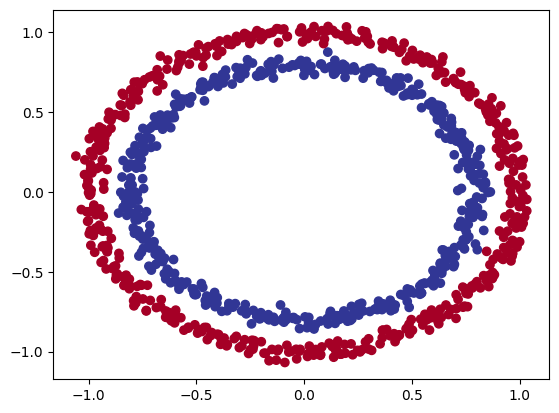

In [7]:
# Lets visualise to learn pattern
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap =plt.cm.RdYlBu)

####Check Input and Output Shapes

In [8]:
X.shape, y.shape

((1000, 2), (1000,))

In [9]:
X_sample =X[0]
y_sample = y[0]

print(f"values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [10]:
import torch
torch.__version__

'2.11.0+cpu'

In [11]:
X.dtype

dtype('float64')

In [12]:
#turning data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

###Splitting data into training and testing splits

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    train_size=0.8,
                                                    random_state=42)

In [14]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

### Lets Build a Model

Building a Model to classify our blue and red dots

To do so we need to:
1. Setup Device agnostic code
2. Construct a model ( by subclassing 'nn.Module')
3. Create a training and test loop

In [15]:
import torch
from torch import nn

#device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

#### Lets create a Model that:

1. Subclasses 'nn.Module'
2. Create 2 'nn.Linear()' layers that are capable of handling the shapes of our data
3. Defines a 'forward()' method that outline the forward pass of the model_selection
4. Instantiate an instance of our model class and send it to the target

In [16]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    #create 2 nn.linear layers
    self.layer_1 = nn.Linear(in_features=2,
                             out_features=5) # 2 input features --> 5 output feature
    self.layer_2 = nn.Linear(in_features =5,
                             out_features=1) # we kept here in_features =5 as because first layer had same inner dimension feature

  def forward(self, x):
    return self.layer_2(self.layer_1(x)) #x --> layer_1 --> layer_2 --> output

model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
#Lets the replicate the model above with nn.sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device) # removes the hustle to create a forward pass but still above is required when building complex layers

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [18]:
#Make some prdctions with the model
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.5146,  0.2795],
                      [ 0.6854,  0.2566],
                      [ 0.5106, -0.3828],
                      [ 0.6729, -0.4502],
                      [-0.3821, -0.0823]])),
             ('0.bias', tensor([-0.6366,  0.1193, -0.4125,  0.0197,  0.6750])),
             ('1.weight',
              tensor([[ 0.3725,  0.0087,  0.1318,  0.0332, -0.3751]])),
             ('1.bias', tensor([-0.3449]))])

In [19]:
#Make Prediction before training
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
  print(f"Length of Predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
  print(f"length of test samples: {len(X_test)}, Shape: {X_test.shape}")
  print(f"First 10 predictions: {untrained_preds[:10]}")
  print(f"First 10 test samples: {y_test[:10]}")


Length of Predictions: 200, Shape: torch.Size([200, 1])
length of test samples: 200, Shape: torch.Size([200, 2])
First 10 predictions: tensor([[-1.0004],
        [-0.8123],
        [-1.2131],
        [-0.9413],
        [-0.7680],
        [-0.6566],
        [-0.4797],
        [-0.4421],
        [-1.2316],
        [-0.7948]])
First 10 test samples: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


## Setup Loss Function and Optimizer

Which loss funtion or Optimizer should we use ?

It is Problem Specific:
1. for Regression - we might want MAE or MSE
2. For classification - we might want BCE or CE (Binary Cross Entropy)

And for Optimizer , two of the most common and useful are SGD and Adam, however PyTorch has many built in options.
for Loss function we would use 'torch.nn.BCEWithLogitsLoss' - as Binary Cross Entropy for Classification

In [20]:
#Setup loss functions
#loss_fn = nn.BCELoss #requires input to have gone through the sigmoid activation function prior to input to BCELoss
# this means we use below code to reduce the effort to do this:
# nn.sequential(
#     nn.sigmoid(),
#     nn.BCELoss()
# )
loss_fn = nn.BCEWithLogitsLoss() #BCEWithLogitLoss = sigmoid activation function built-in

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [21]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.5146,  0.2795],
                      [ 0.6854,  0.2566],
                      [ 0.5106, -0.3828],
                      [ 0.6729, -0.4502],
                      [-0.3821, -0.0823]])),
             ('0.bias', tensor([-0.6366,  0.1193, -0.4125,  0.0197,  0.6750])),
             ('1.weight',
              tensor([[ 0.3725,  0.0087,  0.1318,  0.0332, -0.3751]])),
             ('1.bias', tensor([-0.3449]))])

In [22]:
#Calculate the Accuracy - out of 100, what percentage does our model get correct?
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item
  acc = (correct/len(y_pred))*100
  return acc

#3. Training the Model

To Train our model, we need to perform training loop:

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step (GD)

Our model raw output are going to be called as **Logits**

we can convert these **logits** into Prediction Probabilities by passing them to some
kind of activation func ( e.g sigmoid for binary, softmax for multiclass)

Then we can convert our model probabilities to prediction label by either rounding them or taking argmax()

In [23]:
# View the first 5 outputs of Forward pass on test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-1.0004],
        [-0.8123],
        [-1.2131],
        [-0.9413],
        [-0.7680]])

In [24]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

####Since we need our y_logits output to be in same format as "tensor([1., 0., 1., 0., 1.])" for that we would need rounding off technique to implemented to get our models raw output(logits) into such a form, we can use the **sigmoid** activation function


In [25]:
y_pred_prob = torch.sigmoid(y_logits)
y_pred_prob
#These somehow now in some kind of consistency and they are now in form of prediction probabilities

tensor([[0.2689],
        [0.3074],
        [0.2291],
        [0.2806],
        [0.3169]])

so lets define rule :
* if y_pred_prob >= 0.5 then y=1 (means class 1)
* if y_pred_prob < 0.5 then y=0 (means class 0)

In [26]:
y_preds = torch.round(y_pred_prob)

# In Full ( logits --> pred prob --> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

#check for Equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 0.])

## Building and Testing Loops

In [27]:
import torch # Re-import torch to ensure it refers to the module
torch.manual_seed(42)

epochs =1000
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

for epoch in range(epochs):
  model_0.train()
  #Forward Pass
  y_logits = model_0(X_train.to(device)).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # sigmoid converts logits in prdction probabbilities

  #Calculate the loss
  # loss = loss_fn(torch.sigmoid(y_logits),
  #                y_train)
  loss = loss_fn(y_logits,
                 y_train)
  acc = accuracy_fn(y_true = y_train,
                    y_pred = y_pred)
  #Optimizer zero grad
  optimizer.zero_grad()

  #loss backward
  loss.backward()

  #optimizer step
  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    #1. forward pass
    test_logits = model_0(X_test.to(device)).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    #test loss calculation
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

    # print what happening
    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.79568 | Accuracy: 50.00% | Test Loss: 0.79028 | Test Accuracy: 50.00%
Epoch: 10 | Loss: 0.72782 | Accuracy: 50.00% | Test Loss: 0.72856 | Test Accuracy: 50.00%
Epoch: 20 | Loss: 0.70535 | Accuracy: 50.00% | Test Loss: 0.70758 | Test Accuracy: 50.00%
Epoch: 30 | Loss: 0.69747 | Accuracy: 50.00% | Test Loss: 0.69997 | Test Accuracy: 50.00%
Epoch: 40 | Loss: 0.69463 | Accuracy: 49.38% | Test Loss: 0.69707 | Test Accuracy: 47.50%
Epoch: 50 | Loss: 0.69360 | Accuracy: 44.75% | Test Loss: 0.69592 | Test Accuracy: 47.00%
Epoch: 60 | Loss: 0.69321 | Accuracy: 47.75% | Test Loss: 0.69544 | Test Accuracy: 45.50%
Epoch: 70 | Loss: 0.69307 | Accuracy: 48.75% | Test Loss: 0.69521 | Test Accuracy: 47.00%
Epoch: 80 | Loss: 0.69302 | Accuracy: 50.12% | Test Loss: 0.69510 | Test Accuracy: 46.50%
Epoch: 90 | Loss: 0.69300 | Accuracy: 50.75% | Test Loss: 0.69504 | Test Accuracy: 45.50%
Epoch: 100 | Loss: 0.69299 | Accuracy: 50.62% | Test Loss: 0.69500 | Test Accuracy: 46.50%
Epoch: 110

### Make Predction and Evaluate the model

as from metrics it looks like our model is'nt learning anything...
so to inspect it lets make some predictions and make them visual

In [28]:
import requests
from pathlib import Path

#Download helper function from PyTorch Repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Downloading helper_functions.py")
  request =requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary


Text(0.5, 1.0, 'predictions on train data')

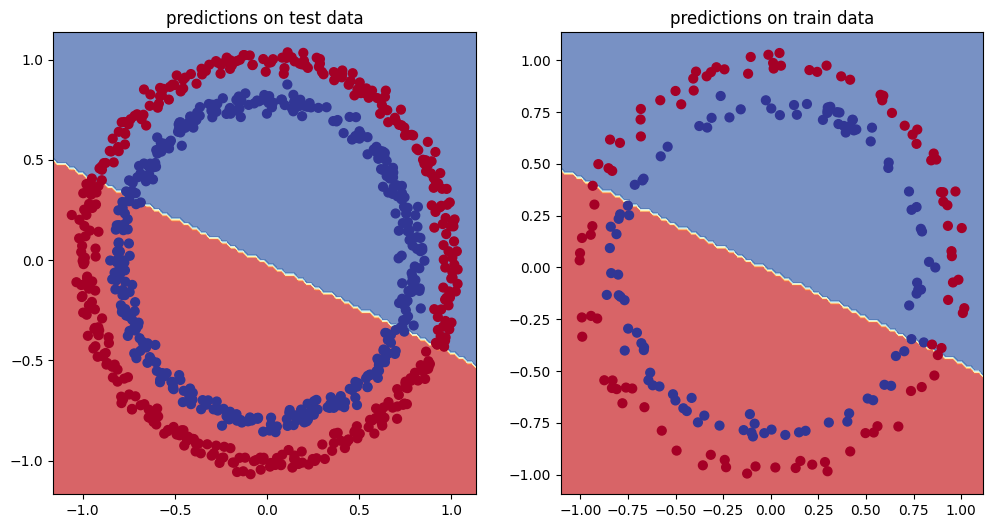

In [29]:
#Plot decision boundary of the model
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.title("predictions on test data")
plt.subplot(1, 2, 2)
plot_decision_boundary(model_0, X_test, y_test)
plt.title("predictions on train data")

### Improving a model (from a model perspective)
 * Add more layer - give the model more chnace to learn about pattern in data.
 * Add more hidden units
 * Changing the Activation function
 * changing the LR ( learning rate)
 * change the loss function

In [30]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.4954,  0.2756],
                      [ 0.6850,  0.2567],
                      [ 0.5090, -0.3815],
                      [ 0.6718, -0.4502],
                      [-0.3629, -0.0782]])),
             ('0.bias', tensor([-0.5408,  0.1218, -0.3986,  0.0257,  0.5789])),
             ('1.weight',
              tensor([[ 0.0786, -0.0126, -0.0672, -0.0046, -0.0838]])),
             ('1.bias', tensor([0.0669]))])

In [31]:
#Adding more hidden units , increase no of layers and increase number epochs...
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    #create 2 nn.linear layers
    self.layer_1 = nn.Linear(in_features=2,
                             out_features=10) # 2 input features --> 10 output feature
    self.layer_2 = nn.Linear(in_features =10,
                             out_features=10) # 10 input features --> 10 output feature
    self.layer_3 = nn.Linear(in_features =10,
                             out_features=1) # 10 input features --> 1 output feature

  def forward(self, x):
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x))) #this way writing opertions leverages speed ups

model_1 = CircleModelV1().to(device)

model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [32]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()
#Create a optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [33]:
# write a training and evaluation loop for model_1
torch.manual_seed(42)

# Train for longer
epochs =1000

#put data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_1.train()
  #Forward Pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  #Calculate the loss /Accuracy
  loss = loss_fn(y_logits,
                 y_train)
  acc = accuracy_fn(y_true = y_train,
                    y_pred = y_pred)

  #Optimizer zero grad
  optimizer.zero_grad()

  #loss backward pass
  loss.backward()

  #Optimize step
  optimizer.step()

  #Testing
  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

  #print out what happening
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 100 | Loss: 0.69305 | Accuracy: 50.38% | Test Loss: 0.69379 | Test Accuracy: 48.00%
Epoch: 200 | Loss: 0.69299 | Accuracy: 51.12% | Test Loss: 0.69437 | Test Accuracy: 46.00%
Epoch: 300 | Loss: 0.69298 | Accuracy: 51.62% | Test Loss: 0.69458 | Test Accuracy: 45.00%
Epoch: 400 | Loss: 0.69298 | Accuracy: 51.12% | Test Loss: 0.69465 | Test Accuracy: 46.00%
Epoch: 500 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69467 | Test Accuracy: 46.00%
Epoch: 600 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 700 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 800 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 900 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%


Text(0.5, 1.0, 'predictions on train data')

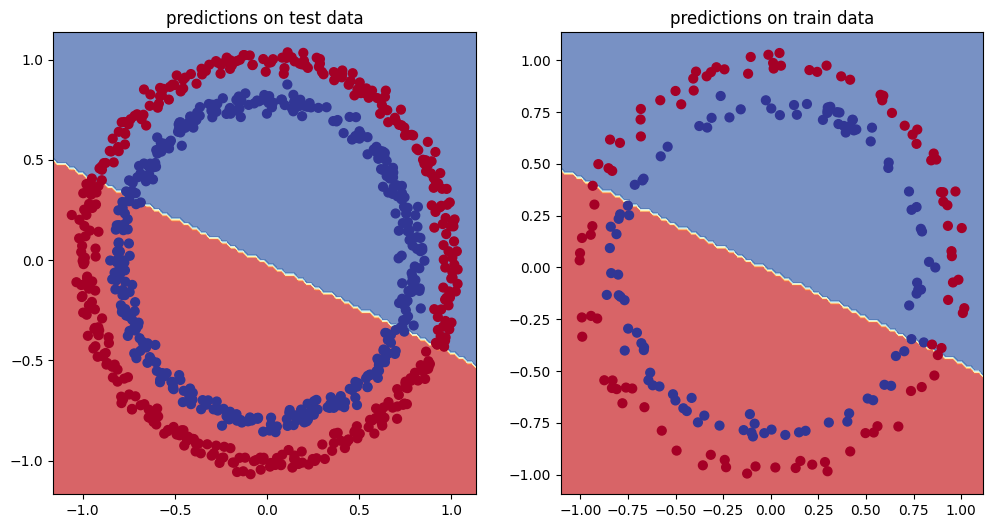

In [34]:
#Lets Plot the decision boundary
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.title("predictions on test data")
plt.subplot(1, 2, 2)
plot_decision_boundary(model_1, X_test, y_test)
plt.title("predictions on train data")

Our model is still drawing a straight line b/w the red and blue dots... means it can do linear data modeling.. like we did in the PyTorch Fundamentals sections

### Preparing data to see if our model can model straight line ?


In [35]:
#Creating Data
weight = 0.7
bias = 0.3
start = 0
end =1
step = 0.01

#Create the Data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

X_regression[:10], y_regression[:10]

#Check the Data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [36]:
#Spliting data into training and testing set
train_split = int(0.8*len(X_regression))
X_train_reg, y_train_reg = X_regression[:train_split], y_regression[:train_split]
X_test_reg, y_test_reg = X_regression[train_split:], y_regression[train_split:]

len(X_train_reg), len(y_train_reg), len(X_test_reg), len(y_test_reg)

(80, 80, 20, 20)

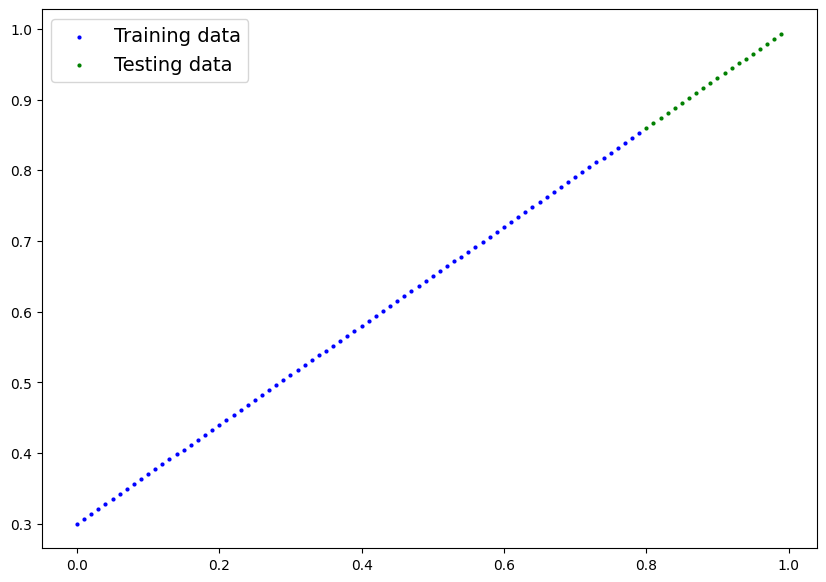

In [37]:
plot_predictions(train_data= X_train_reg, train_labels = y_train_reg,
                 test_data=X_test_reg,
                 test_labels=y_test_reg,
                 predictions=None)
#

### Now Adjusting model_1 to fit staright line

In [38]:
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [39]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.01)

In [40]:
##Training the Model (model_2)
torch.manual_seed(42)

epochs = 1000

#put data to target device
X_train_reg, y_train_reg = X_train_reg.to(device), y_train_reg.to(device)
X_test_reg, y_test_reg = X_test_reg.to(device), y_test_reg.to(device)

for epoch in range(epochs):
  model_2.train()
  #Forward Pass
  y_pred = model_2(X_train_reg)
  #Calculate loss
  loss = loss_fn(y_pred, y_train_reg)
  #optimizer zero grad
  optimizer.zero_grad()
  #loss backward
  loss.backward()
  #optimizer step
  optimizer.step()

  #Testing
  model_2.eval()
  with torch.inference_mode():
    #forward pass
    test_pred = model_2(X_test_reg)
    #calculate the loss
    test_loss = loss_fn(test_pred, y_test_reg)

  if epoch % 100 ==0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")


Epoch: 0 | Loss: 0.75986 | Test Loss: 0.91103
Epoch: 100 | Loss: 0.02858 | Test Loss: 0.00081
Epoch: 200 | Loss: 0.02533 | Test Loss: 0.00209
Epoch: 300 | Loss: 0.02137 | Test Loss: 0.00305
Epoch: 400 | Loss: 0.01964 | Test Loss: 0.00341
Epoch: 500 | Loss: 0.01940 | Test Loss: 0.00387
Epoch: 600 | Loss: 0.01903 | Test Loss: 0.00379
Epoch: 700 | Loss: 0.01878 | Test Loss: 0.00381
Epoch: 800 | Loss: 0.01840 | Test Loss: 0.00329
Epoch: 900 | Loss: 0.01798 | Test Loss: 0.00360


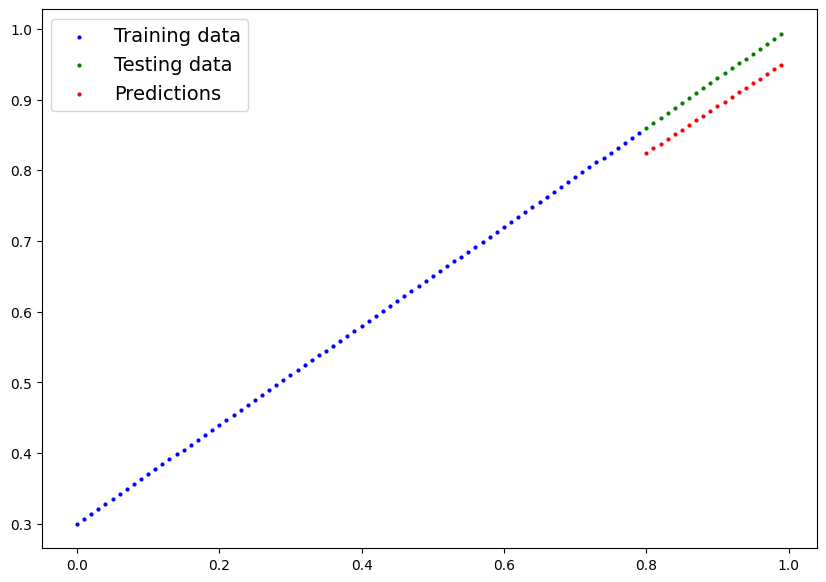

In [41]:
## Turn on Evaluation mode
model_2.eval()

#make predictions
with torch.inference_mode():
  y_preds = model_2(X_test_reg)

#plot the data and predictions with data on the CPU as matplotlib cannot run on GPU

plot_predictions(train_data= X_train_reg.cpu(), train_labels = y_train_reg.cpu(),
                 test_data=X_test_reg.cpu(),
                 test_labels=y_test_reg.cpu(),
                 predictions = y_preds.cpu());

### NON-LINEARITY
"What pattern could you draw if you were given an infinite amount of a straight and non-straight lines"

#### Recreating the non-linear data (red and blue circles)

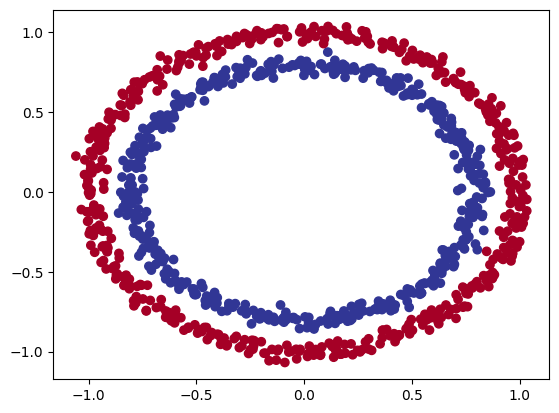

In [42]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [43]:
# Convert data to tensor and then to train and test splits
import torch
from sklearn.model_selection import train_test_split

#turn data in tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### Building a model with Non - Linearity


 #### we would be using PyTorch Non-Linear activation functions (ready-made) and one of the most common one is Rectified linear Unit (ReLU) used as "torch.nn.ReLU()"

In [44]:
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()
    #Can also put sigmoid in the model
    #this would mean you don't need to use it on the predictions
    #self.sigmoid = nn.sigmoid()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.layer_1(x))))

model_3 = CircleModelV2().to(device)
print(model_3)

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


###Now as we have got our model ready, lets create binary classification:
* Loss Function
* Optimizer

In [45]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)
#

##Training a model with Non-Linearity

In [46]:
torch.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
print(X_train.shape, X_train.dtype)
# print(X[0:10,0:10])

for epoch in range(epochs):
  #Forward pass
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))
  #Calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
  #optimizer zero grad
  optimizer.zero_grad()

  #loss backward
  loss.backward()

  #optimizer step
  optimizer.step()

  #Testing
  model_3.eval()
  with torch.inference_mode():
    #forward pass
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    #calculate the loss and accuracy
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

torch.Size([800, 2]) torch.float32
Epoch: 0 | Loss: 0.69833 | Accuracy: 50.00% | Test Loss: 0.69863 | Test Accuracy: 49.00%
Epoch: 100 | Loss: 0.69289 | Accuracy: 50.88% | Test Loss: 0.69411 | Test Accuracy: 47.00%
Epoch: 200 | Loss: 0.69015 | Accuracy: 53.37% | Test Loss: 0.69141 | Test Accuracy: 50.00%
Epoch: 300 | Loss: 0.68762 | Accuracy: 56.62% | Test Loss: 0.68828 | Test Accuracy: 55.00%
Epoch: 400 | Loss: 0.68469 | Accuracy: 60.00% | Test Loss: 0.68469 | Test Accuracy: 61.00%
Epoch: 500 | Loss: 0.67985 | Accuracy: 56.00% | Test Loss: 0.67890 | Test Accuracy: 60.50%
Epoch: 600 | Loss: 0.67280 | Accuracy: 56.00% | Test Loss: 0.67176 | Test Accuracy: 60.50%
Epoch: 700 | Loss: 0.66304 | Accuracy: 64.50% | Test Loss: 0.66452 | Test Accuracy: 65.00%
Epoch: 800 | Loss: 0.64710 | Accuracy: 74.12% | Test Loss: 0.65300 | Test Accuracy: 71.50%
Epoch: 900 | Loss: 0.62182 | Accuracy: 81.62% | Test Loss: 0.63241 | Test Accuracy: 78.00%


Text(0.5, 1.0, 'predictions on train data')

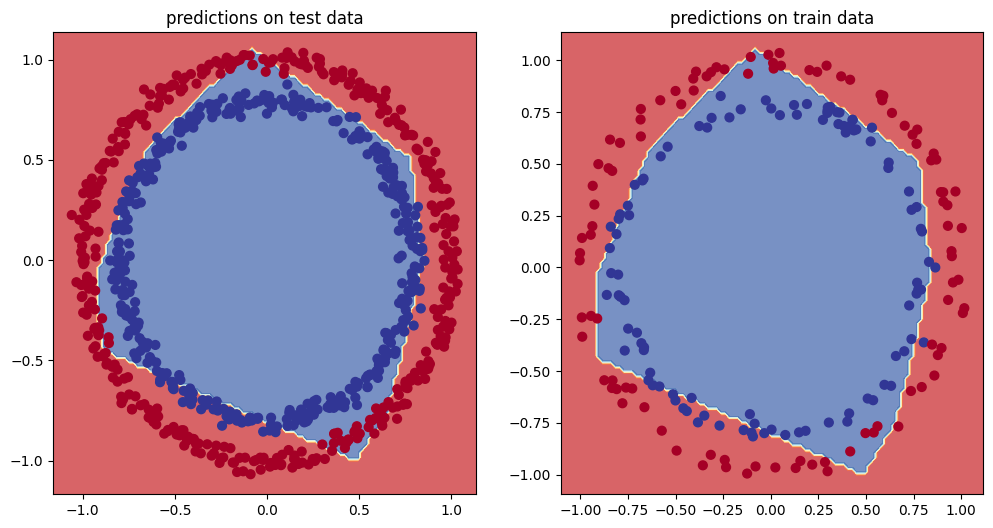

In [47]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.title("predictions on test data")
plt.subplot(1, 2, 2)
plot_decision_boundary(model_3, X_test, y_test)
plt.title("predictions on train data")

## Replicating Non-Linear Activation Functions

### ***As we know how the ReLU() - works and maths behind we would now try to create our own Rectified Linear Units functions***
which gives exatly same as output when input is positive and greater than zero else always returns 0 for all negatives values.

In [48]:
#lets first create a data for non-linearity
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

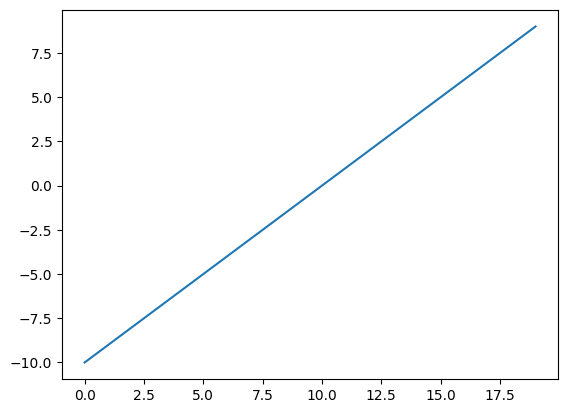

In [49]:
plt.plot(A)
#it shows a linear line in the graph

In [50]:
from numpy import maximum
#self defined relu function
def relu(x):
  return maximum(torch.tensor(0), x)

relu(A)

/tmp/ipykernel_3764/260641471.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return maximum(torch.tensor(0), x)


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.], dtype=torch.float64)

/tmp/ipykernel_3764/260641471.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return maximum(torch.tensor(0), x)


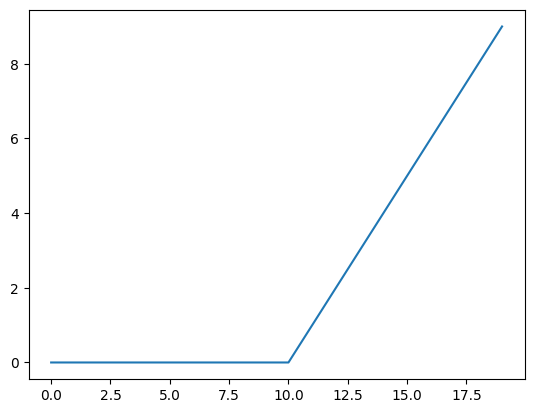

In [51]:
#lets visualise the ReLU() in graphical image
plt.plot(relu(A))

### We can see the another activation function as Sigmoid by creating our own function rather than using PyTorch built-in function:
Maths behind Sigmoid Function:
      
S(x) = 1/ 1 + e^(-x)


In [52]:
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

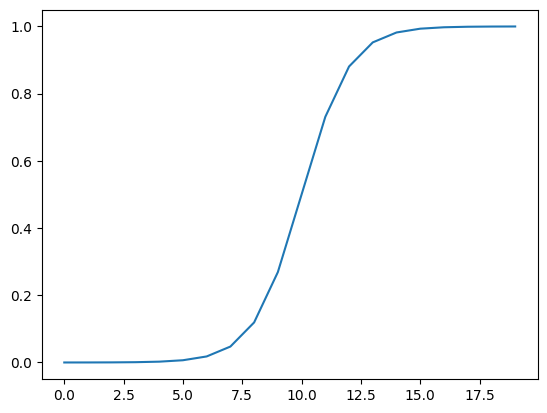

In [53]:
plt.plot(sigmoid(A))

# Creating a Multi Class Classification Model - PyTorch
Process to build multi-class model
1. Preparing Multi class data
2. Building Classification model
3. Training multi class classification model
4. Creating loss func and optimizer for multi class model
5. Creating prediction for multi class model
6. Creating training and testing loop for multi class model
7. Evaluating the multi class model predictions

### 1. Preparing data for Multi class

In [54]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

#set Hyperperameters
NUM_CLASS=4
NUM_FEATURES=2
RANDOM_SEED=42

#Create data
X_mc, y_mc = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES, #no. of features each sample has (here 2d shape)
                            centers=NUM_CLASS, # no of distinct labels in the data
                            cluster_std=1.5,  # give the clusters a little shake up
                            random_state=RANDOM_SEED)
# 2. Turn data into tensors
X_mc = torch.from_numpy(X_mc).type(torch.float)
y_mc = torch.from_numpy(y_mc).type(torch.LongTensor)
print(X_mc[:5], y_mc[:5])

#Split the data into train and test
X_mc_train, X_mc_test, y_mc_train, y_mc_test = train_test_split(X_mc, y_mc, test_size=0.2, random_state=RANDOM_SEED)

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


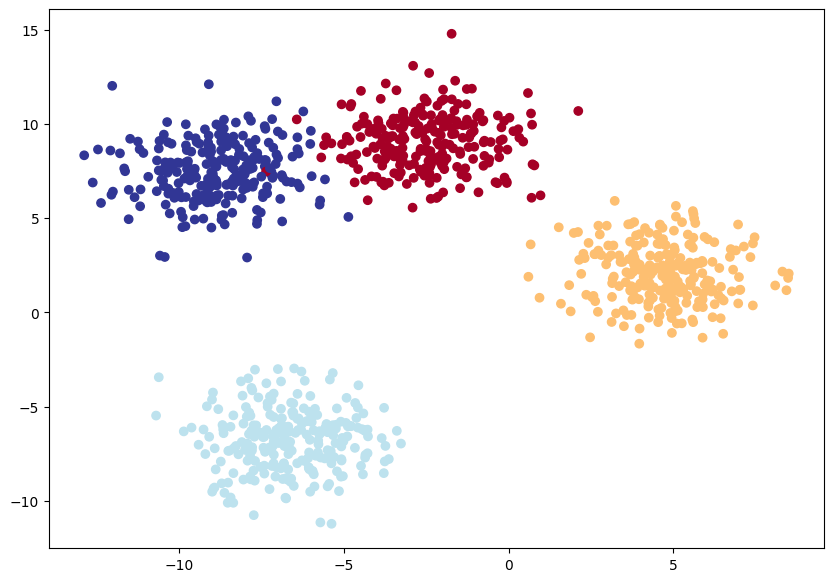

In [55]:
# 4. Plot data
plt.figure(figsize=(10, 7))
plt.scatter(X_mc[:, 0], X_mc[:, 1], c=y_mc, cmap=plt.cm.RdYlBu);

###Building Multi Class Classification Model in PyTorch

In [56]:
from torch import nn

class MultiClassModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units):
    super().__init__()
    self.linear_layer_stack=nn.Sequential(
     nn.Linear(in_features = input_features, out_features=hidden_units, bias=True),
     nn.Linear(in_features = hidden_units, out_features=hidden_units, bias=True),
     nn.Linear(in_features = hidden_units, out_features=output_features, bias=True)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

model_4 = MultiClassModel(input_features=NUM_FEATURES,
                    output_features=NUM_CLASS,
                    hidden_units=8).to(device)
model_4

MultiClassModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

### Creating loss function and Optimizer

In [57]:
loss_fn = torch.nn.CrossEntropyLoss() #is one best loss function for Multi class classification
optimizer = torch.optim.SGD(model_4.parameters(),
                            lr=0.1)

### Taking Predictions from the model (multi class)

In [58]:
model_4(X_mc_train.to(device))[:5]

tensor([[-1.2711, -0.6494, -1.4740, -0.7044],
        [ 0.2210, -1.5439,  0.0420,  1.1531],
        [ 2.8698,  0.9143,  3.3169,  1.4027],
        [ 1.9576,  0.3125,  2.2244,  1.1324],
        [ 0.5458, -1.2381,  0.4441,  1.1804]], grad_fn=<SliceBackward0>)

here we can that we are getting one value for each feature from our model

### Training our multi class model

as we used Sigmoid for converting values in Probabilities for Binary CLassification model, similarly we would need 'Softmax' for the prediction probability for multi class model



In [59]:
#make prediction logits with model
logits = model_4(X_mc_test.to(device))

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
y_pred_prob = torch.softmax(logits, dim=1)
print(logits[:5])
print(y_pred_prob[:5])


tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]], grad_fn=<SliceBackward0>)
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]], grad_fn=<SliceBackward0>)


#### we can see that After passing the logits through the softmax function, each individual sample now adds to 1 (or very close to).
Let's Check:

In [60]:
torch.sum(y_pred_prob[0])

tensor(1., grad_fn=<SumBackward0>)

Since there's one value for each class in y_pred_probs, the index of the highest value is the class the model thinks the specific data sample most belongs to.

We can check which index has the highest value using 'torch.argmax()'.

In [61]:
print(y_pred_prob[0])
print(torch.argmax(y_pred_prob[0])) # returns index of highest value


tensor([0.1872, 0.2918, 0.1495, 0.3715], grad_fn=<SelectBackward0>)
tensor(3)


####these predictions are right now random and thats we need to train to make predictions strong and confident
## Creating Training and testing loop for multi class classification

In [62]:
torch.manual_seed(42)

epochs=100

X_mc_train, y_mc_train = X_mc_train.to(device), y_mc_train.to(device)
X_mc_test, y_mc_test = X_mc_test.to(device), y_mc_test.to(device)

for epoch in range(epochs):
  model_4.train()
  #Forward Pass
  y_logits = model_4(X_mc_train)

  # Calculate predicted labels for training accuracy
  y_train_pred_prob = torch.softmax(y_logits, dim=1)
  y_train_pred_labels = torch.argmax(y_train_pred_prob, dim=1) #logits ---> prob ----> labels

  #Calculate the loss
  loss = loss_fn(y_logits, y_mc_train)
  acc = accuracy_fn(y_true=y_mc_train,
                    y_pred=y_train_pred_labels)
  #optimizer zero grad
  optimizer.zero_grad()

  #loss backward
  loss.backward()

  #optimizer step
  optimizer.step()

  #Testing
  model_4.eval()
  with torch.inference_mode():
    #forward pass
    test_logits = model_4(X_mc_test)
    test_pred_prob = torch.softmax(test_logits, dim=1)
    test_pred = torch.argmax(test_pred_prob, dim=1)
    test_loss = loss_fn(test_logits, y_mc_test)
    test_acc = accuracy_fn(y_true= y_mc_test,
                           y_pred=test_pred)
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc}% |")

Epoch: 0 | Loss: 1.04324 | Accuracy: 65.50% | Test Loss: 0.57861 | Test Accuracy: 95.5% |
Epoch: 10 | Loss: 0.14398 | Accuracy: 99.12% | Test Loss: 0.13037 | Test Accuracy: 99.0% |
Epoch: 20 | Loss: 0.08062 | Accuracy: 99.12% | Test Loss: 0.07216 | Test Accuracy: 99.5% |
Epoch: 30 | Loss: 0.05924 | Accuracy: 99.12% | Test Loss: 0.05133 | Test Accuracy: 99.5% |
Epoch: 40 | Loss: 0.04892 | Accuracy: 99.00% | Test Loss: 0.04098 | Test Accuracy: 99.5% |
Epoch: 50 | Loss: 0.04295 | Accuracy: 99.00% | Test Loss: 0.03486 | Test Accuracy: 99.5% |
Epoch: 60 | Loss: 0.03910 | Accuracy: 99.00% | Test Loss: 0.03083 | Test Accuracy: 99.5% |
Epoch: 70 | Loss: 0.03643 | Accuracy: 99.00% | Test Loss: 0.02799 | Test Accuracy: 99.5% |
Epoch: 80 | Loss: 0.03448 | Accuracy: 99.00% | Test Loss: 0.02587 | Test Accuracy: 99.5% |
Epoch: 90 | Loss: 0.03300 | Accuracy: 99.12% | Test Loss: 0.02423 | Test Accuracy: 99.5% |


###while we have trained our model, now lets gets some predictions from the model

In [63]:
# Make predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_mc_test)

# View the first 10 predictions
y_logits[:10]

tensor([[  4.3377,  10.3539, -14.8948,  -9.7642],
        [  5.0142, -12.0371,   3.3860,  10.6699],
        [ -5.5885, -13.3448,  20.9894,  12.7711],
        [  1.8400,   7.5599,  -8.6016,  -6.9942],
        [  8.0727,   3.2906, -14.5998,  -3.6186],
        [  5.5844, -14.9521,   5.0168,  13.2891],
        [ -5.9739, -10.1913,  18.8655,   9.9179],
        [  7.0755,  -0.7601,  -9.5531,   0.1736],
        [ -5.5918, -18.5990,  25.5310,  17.5799],
        [  7.3142,   0.7197, -11.2017,  -1.2011]])

In [64]:
#this is still making predictions in logit, lets convert them into prediction probability
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_mc_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_mc_test, y_pred=y_preds)}%")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])
Test accuracy: 99.5%


Text(0.5, 1.0, 'predictions on train data')

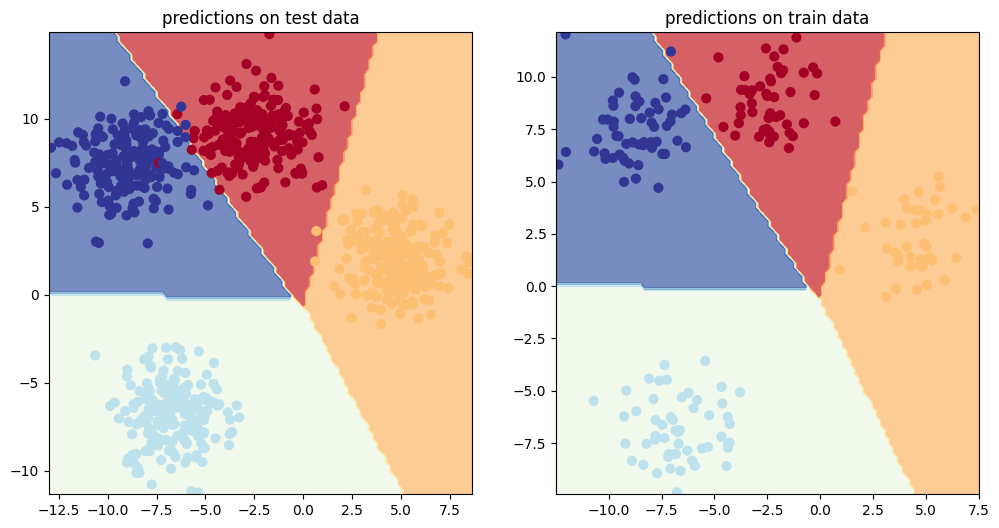

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_mc_train, y_mc_train)
plt.title("predictions on test data")
plt.subplot(1, 2, 2)
plot_decision_boundary(model_4, X_mc_test, y_mc_test)
plt.title("predictions on train data")